# 03 — Supervised Fine-Tuning (SFT) with Qwen

Fine-tune a Qwen3.5 model on the DAIC-WOZ clinical interview data using LoRA + TRL's `SFTTrainer`.

The dataset (`daicwoz_finetune.jsonl`) is already in chat format — each line is a full interview formatted as `{"messages": [{role, content}, ...]}`.


In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

import json
import os
from pathlib import Path

import torch
torch.cuda.empty_cache()
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


## Configuration

In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen3.5-4B"

# ── Paths ──────────────────────────────────────────────────────────────────
SSD_ROOT    = Path(os.environ["SSD_ROOT"])
TRAIN_PATH  = Path("../data/processed/combined_train_chunked.jsonl")
VAL_PATH    = Path("../data/processed/combined_val_chunked.jsonl")
OUTPUT_DIR  = SSD_ROOT / "models/Qwen3.5-4B-SFT"

# ── LoRA ───────────────────────────────────────────────────────────────────
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05

# ── Training ───────────────────────────────────────────────────────────────
NUM_EPOCHS     = 3
BATCH_SIZE     = 1
GRAD_ACCUM     = 8
LR             = 3e-5

MAX_SEQ_LENGTH = 4096

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Model : {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")

Model : Qwen/Qwen3.5-4B
Output: /data_1_8TB_ssd/kevint/models/Qwen3.5-4B-SFT-newdata


## Load Dataset

In [3]:
def load_jsonl(path):
    """Load JSONL records as-is (no trimming, no turn removal)."""
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_records = load_jsonl(TRAIN_PATH)
val_records   = load_jsonl(VAL_PATH)

train_dataset = Dataset.from_list(train_records)
val_dataset   = Dataset.from_list(val_records)

print(f"Train: {len(train_dataset)}")
print(f"Val  : {len(val_dataset)}")
print(f"\nExample (first 2 turns):")
for msg in train_dataset[0]["messages"][:2]:
    print(f"  [{msg['role']}]: {msg['content'][:120]!r}")

Train: 202
Val  : 29

Example (first 2 turns):
  [system]: 'You are a virtual clinical interviewer. Conduct a structured, empathetic mental health interview by asking open-ended qu'
  [user]: 'Start the session.'


## Load Tokenizer & Model

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"   # required for causal LM training

dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
)
model.config.use_cache = False
# Explicitly align pad/eos token IDs so transformers doesn't auto-correct and warn
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
if hasattr(model, "generation_config"):
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parameters  : {total:,}  (trainable before LoRA: {trainable:,})")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

/data_1_8TB_ssd/kevint/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Parameters  : 2,421,206,016  (trainable before LoRA: 636,660,736)


## Apply LoRA

In [5]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 21,233,664 || all params: 4,226,984,960 || trainable%: 0.5023


## Train

In [6]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

sft_config = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    # Logging & saving
    logging_steps=10,
    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,
    # Evaluation
    eval_strategy="steps",
    eval_steps=10,
    per_device_eval_batch_size=BATCH_SIZE,
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    # Precision
    bf16=use_bf16,
    fp16=(not use_bf16) and torch.cuda.is_available(),
    # Misc
    gradient_checkpointing=True,
    report_to="none",
    max_length=MAX_SEQ_LENGTH,
    dataset_kwargs={"skip_prepare_dataset": False},
    assistant_only_loss=True,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

print("Trainer ready  (assistant-only loss)")
print(f"Steps per epoch : {len(trainer.get_train_dataloader())}")
print(f"Total steps     : {sft_config.max_steps if sft_config.max_steps > 0 else 'auto'}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/29 [00:00<?, ? examples/s]

Trainer ready  (assistant-only loss)
Steps per epoch : 202
Total steps     : auto


In [7]:
train_result = trainer.train()

print("\n── Training complete ──")
print(f"Runtime    : {train_result.metrics['train_runtime']:.1f}s")
print(f"Samples/s  : {train_result.metrics['train_samples_per_second']:.2f}")
print(f"Final loss : {train_result.metrics['train_loss']:.4f}")


[transformers] Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.012115,2.085823,1.728560,183851.000000,0.526047
20,1.971912,2.028785,1.805926,367307.000000,0.531992
30,1.991733,1.998620,1.832498,522111.000000,0.538062
40,1.918958,1.982376,1.845901,706314.000000,0.540707
50,1.949188,1.973843,1.853141,887852.000000,0.541655
60,1.901372,1.969872,1.856364,1064637.000000,0.542670
70,1.903063,1.969504,1.857181,1236629.000000,0.542672
78,1.903063,1.969224,1.856695,1372260.000000,0.542950



── Training complete ──
Runtime    : 879.8s
Samples/s  : 0.69
Final loss : 1.9439


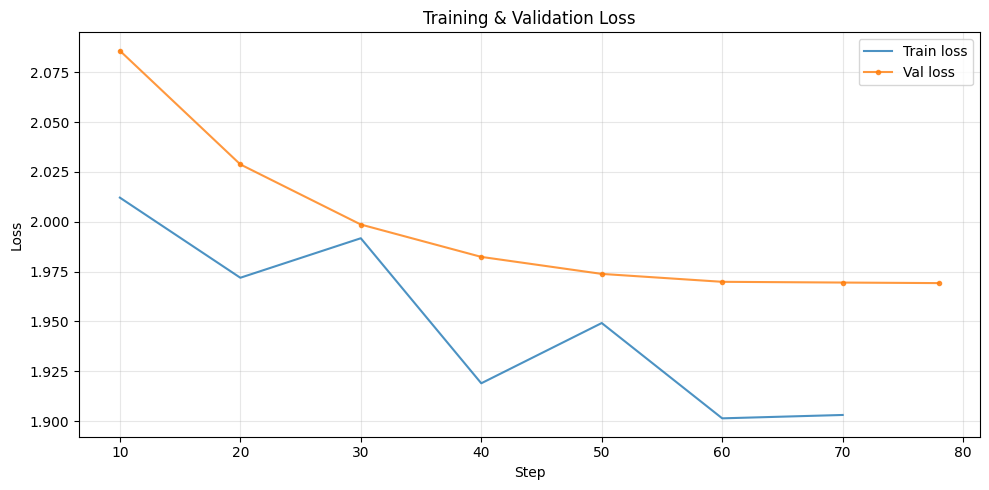

In [8]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [e["step"] for e in log_history if "loss" in e]
train_loss  = [e["loss"] for e in log_history if "loss" in e]
eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train loss", alpha=0.8)
ax.plot(eval_steps,  eval_loss,  label="Val loss",   alpha=0.8, marker="o", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Save Model

In [9]:
adapter_dir = OUTPUT_DIR / "lora-adapters"
model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))
print(f"LoRA adapters saved → {adapter_dir}")

LoRA adapters saved → /data_1_8TB_ssd/kevint/models/Qwen3.5-4B-SFT-newdata/lora-adapters


## Quick Inference Test

In [10]:
import time
import warnings
warnings.filterwarnings("ignore", message="tl.make_block_ptr is deprecated")

# Re-enable KV cache for inference (was disabled during training)
model.config.use_cache = True
if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

def generate_response(mdl, test_msgs, max_new_tokens=128):
    mdl.eval()
    prompt_text = tokenizer.apply_chat_template(
        test_msgs,
        add_generation_prompt=True,
        tokenize=False,
        enable_thinking=False
    )
    encoded = tokenizer(prompt_text, return_tensors="pt")
    input_ids = encoded.input_ids.to(mdl.device)
    attention_mask = encoded.attention_mask.to(mdl.device)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    t0 = time.perf_counter()
    stop_ids = list({tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<|im_end|>")})
    with torch.no_grad():
        out = mdl.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=1,
            top_p=0.9,
            top_k=50, 
            eos_token_id=stop_ids,
            pad_token_id=tokenizer.pad_token_id,
        )
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    elapsed = time.perf_counter() - t0
    new_tokens = out[0][input_ids.shape[-1]:]
    tokens_generated = len(new_tokens)
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response, elapsed, tokens_generated


SYSTEM_PROMPT = """\
You are an expert therapist conducting a structured clinical mental health interview \
using Cognitive Behavioral Therapy (CBT) principles. Your role is to build rapport, \
assess the patient's presenting concerns, and collaboratively begin to identify \
the cognitive and behavioral patterns maintaining their distress.

Follow these CBT-grounded guidelines throughout the conversation:

1. Therapeutic stance — Be warm, genuine, and non-judgmental. Use Socratic questioning \
to gently guide the patient toward their own insights rather than lecturing or advising directly.

2. Agenda-setting — Early in the session, briefly orient the patient to what you will \
explore together (e.g., current mood, thoughts, behaviors, and their interconnections).

3. Cognitive assessment — Explore automatic thoughts, core beliefs, and cognitive \
distortions (e.g., catastrophizing, all-or-nothing thinking, mind-reading). Ask the \
patient what went through their mind in specific situations.

4. Behavioral assessment — Inquire about activity levels, avoidance behaviors, \
sleep, appetite, social withdrawal, and any behaviors that perpetuate or relieve distress.

5. Thought-behavior-emotion links — Help the patient notice connections between \
situations, thoughts, feelings, and behaviors using the CBT model (e.g., "When that \
thought came up, what did you feel in your body? And what did you do next?").

6. Symptom domains — Systematically cover mood (depression, anxiety, irritability), \
energy, sleep, concentration, anhedonia, hopelessness, and any safety concerns.

7. Safety — If the patient expresses hopelessness, worthlessness, or any hint of \
self-harm or suicidal ideation, respond with direct, compassionate inquiry and \
appropriate risk assessment (e.g., "Have you had any thoughts of hurting yourself?").

8. Empathic reflection — Regularly reflect and summarize what the patient shares \
before moving to a new topic. Validate emotions without reinforcing unhelpful beliefs.

9. Open-ended questions — Prefer open-ended questions (e.g., "Tell me more about \
that", "What does that feel like for you?") over leading or yes/no questions.

10. Pacing — Respond to one idea at a time. Do not overwhelm the patient with \
multiple questions in a single turn."""

test_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": "Please begin the session."}
]

response, elapsed, n_tokens = generate_response(model, test_messages)
print(response)

/data_1_8TB_ssd/kevint/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Hello, I'm glad you've made the time to meet with me today. Before we dive into the details, I'd like to set the agenda for our conversation so we can get the most out of our time together.

To begin, we'll start by checking in on how you're feeling right now. How has your mood been lately? From there, we can look at the thoughts and behaviors that might be contributing to these feelings. This includes exploring what goes through your mind, any physical sensations you might notice, and how you're spending your time.

Whenever you feel ready, share a bit about what's on your mind
